# Counterfactuals and causal discovery

Everything in the previous three notebooks explains **a model**: which inputs did
this network weigh? That is a genuinely useful question, but it has a hard
limit — if the model learned a confounded shortcut, a *faithful* attribution
will faithfully report the shortcut. Saliency cannot tell you the thing it
highlighted is not causal.

This notebook covers the two method families that push past that, and they are
different from each other:

1. **Counterfactuals** — still about the model, but asking a stronger question:
   *what is the smallest change to this signal that would flip the decision?*
   Closer to how a clinician reasons, and it yields an actionable edit rather
   than a heatmap.
2. **Causal discovery** — not about the model at all. Which variables actually
   drive which others in the data-generating process?

For wearables that second distinction is the difference between *"the model
looked at the accelerometer channel"* and *"movement drives heart-rate change"*.
Only the latter survives a change in deployment conditions, and only the latter
supports an intervention.

## What is in `src/`

Full developer notes: [`src/ts_interp/README.md`](../../src/ts_interp/README.md).
Used here: `counterfactual.nun_counterfactual` (Native-Guide / NUN-CF splicing)
and `causal.{make_causal_dataset, granger_causality, conditional_granger,
discover_graph, score_graph}`.

In [1]:
import sys
sys.path.insert(0, "../../src")

import numpy as np
import matplotlib.pyplot as plt

from ts_interp import data, model, counterfactual, causal

np.random.seed(0)

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Part 1 — Counterfactual explanations

The method here is **Native-Guide / NUN-CF** (Delaney et al.,
[*Instance-based Counterfactual Explanations for Time Series Classification*](https://arxiv.org/abs/2009.13211),
2021):

1. Find the **nearest unlike neighbour** (NUN) — the closest training instance
   with a different label.
2. Splice the **shortest contiguous segment** from that donor into the query
   until the prediction flips.

The appeal is that the counterfactual stays **on the data manifold**: every
value in it came from a real signal of the target class. That is what separates
this from an adversarial perturbation, which flips the label with imperceptible
noise and explains nothing.

In [2]:
ds = data.make_multivariate_dataset(
    n_samples=600, length=192, crosstalk=0.7, event_sec=0.8, seed=0
)
train_ds, test_ds = data.train_test_split(ds, test_frac=0.25, seed=0)

clf = model.TSClassifier(n_channels=3, n_classes=4, hidden=32)
model.train(clf, train_ds.x, train_ds.y, epochs=60)
print(f"test accuracy: {model.accuracy(clf, test_ds.x, test_ds.y):.3f}")

test accuracy: 1.000


original class : 2
counterfactual : 0
spliced segment: (84, 120)  (36/192 samples, 19% of the signal)
true event window: (np.int64(86), np.int64(137))


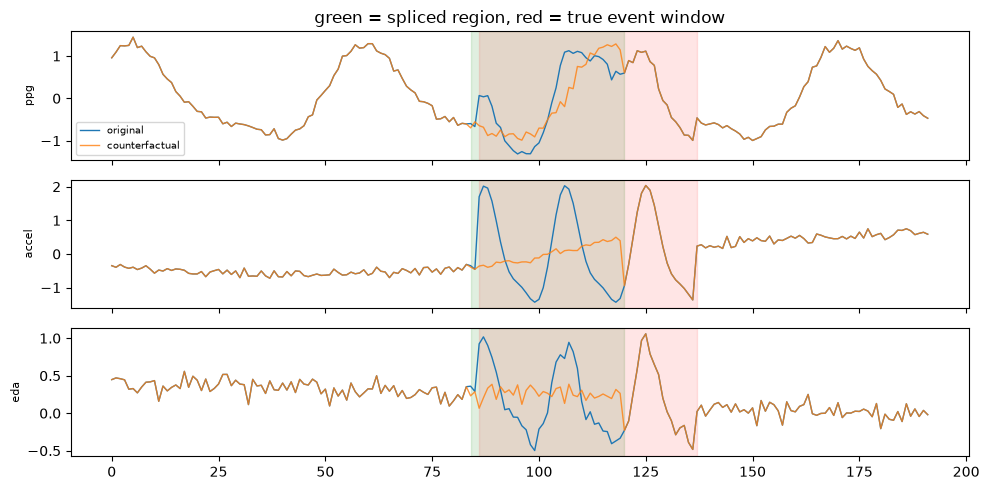

In [3]:
idx = np.where(test_ds.y > 0)[0][0]
x = test_ds.x[idx]
window = tuple(test_ds.event_windows[idx])

cf = counterfactual.nun_counterfactual(clf, x, train_ds.x, train_ds.y, step=4)

print(f"original class : {cf.original_class}")
print(f"counterfactual : {cf.cf_class}")
print(f"spliced segment: {cf.segment}  ({cf.n_changed}/{x.shape[-1]} samples, "
      f"{100*cf.n_changed/x.shape[-1]:.0f}% of the signal)")
print(f"true event window: {window}")

fig, axes = plt.subplots(3, 1, figsize=(10, 5), sharex=True)
for k, ax in enumerate(axes):
    ax.plot(x[k], label="original", lw=1)
    ax.plot(cf.x_cf[k], label="counterfactual", lw=1, alpha=0.8)
    ax.axvspan(*cf.segment, color="green", alpha=0.12)
    ax.axvspan(*window, color="red", alpha=0.10)
    ax.set_ylabel(ds.channel_names[k], fontsize=8)
axes[0].set_title("green = spliced region, red = true event window")
axes[0].legend(fontsize=7)
plt.tight_layout(); plt.show()

### Does the minimal edit land on the event?

If the counterfactual machinery is working, the shortest prediction-flipping
splice should overlap the region that actually defines the class. That overlap
is a sanity check on the *explanation*, computed against ground truth we control.

In [4]:
event_idx = np.where(test_ds.y > 0)[0][:30]
flipped, lengths, overlaps = 0, [], []

for i in event_idx:
    cfi = counterfactual.nun_counterfactual(clf, test_ds.x[i], train_ds.x, train_ds.y, step=4)
    if not cfi.success:
        continue
    flipped += 1
    lengths.append(cfi.n_changed)
    s, e = cfi.segment
    ts, te_ = test_ds.event_windows[i]
    inter = max(0, min(e, te_) - max(s, ts))
    overlaps.append(inter / (e - s))

print(f"flipped {flipped}/{len(event_idx)} samples")
print(f"mean spliced length : {np.mean(lengths):.1f} / {test_ds.x.shape[-1]} samples "
      f"({100*np.mean(lengths)/test_ds.x.shape[-1]:.0f}%)")
print(f"mean fraction of the splice inside the true event window: {np.mean(overlaps):.2f}")

flipped 30/30 samples
mean spliced length : 24.5 / 192 samples (13%)
mean fraction of the splice inside the true event window: 0.99


## Part 2 — Causal discovery

Now we drop the classifier entirely. The question is no longer "what did the
model use" but "what drives what".

The simulated system has a known lagged graph:

```
sleep_debt --(lag 3)--> activity
activity   --(lag 2)--> heart_rate
activity   --(lag 4)--> eda
heart_rate --(lag 1)--> hrv          (negative coefficient)
```

With a trap built in on purpose: **`heart_rate` and `eda` are both driven by
`activity`**, so they are strongly correlated with each other despite having no
direct link. This is exactly the structure that makes naive analysis produce a
confident, wrong conclusion — and exactly what a wearable dataset looks like,
where nearly everything is downstream of movement.

variables: ('sleep_debt', 'activity', 'heart_rate', 'hrv', 'eda')
true edges: (('sleep_debt', 'activity', 3), ('activity', 'heart_rate', 2), ('heart_rate', 'hrv', 1), ('activity', 'eda', 4))


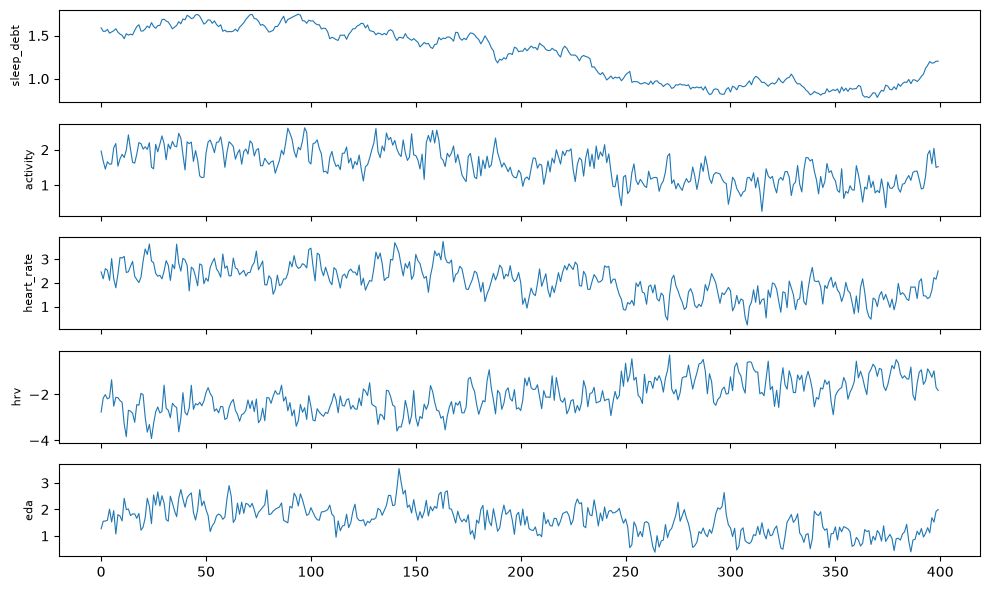

In [5]:
cds = causal.make_causal_dataset(n_timesteps=3000, seed=0)
print("variables:", cds.var_names)
print("true edges:", cds.true_edges)

fig, axes = plt.subplots(5, 1, figsize=(10, 6), sharex=True)
for k, ax in enumerate(axes):
    ax.plot(cds.x[k][:400], lw=0.8)
    ax.set_ylabel(cds.var_names[k], fontsize=8)
plt.tight_layout(); plt.show()

### Pairwise vs. conditional Granger

- **Pairwise Granger** asks: does X's past improve prediction of Y's future
  beyond Y's own past? It conditions on *nothing else*.
- **Conditional Granger** asks the same, but with every *other* variable's past
  already in the restricted model. A link that survives is not explained by any
  other observed variable's history — that is the core idea PCMCI builds on.

Watch the `heart_rate -> eda` pair specifically.

In [6]:
i_hr = cds.var_names.index("heart_rate")
i_eda = cds.var_names.index("eda")
i_act = cds.var_names.index("activity")

f_p, p_p = causal.granger_causality(cds.x, i_hr, i_eda, max_lag=5)
f_c, p_c = causal.conditional_granger(cds.x, i_hr, i_eda, max_lag=5)

print("heart_rate -> eda   (NO direct edge in the true graph)")
print(f"  pairwise    : F={f_p:8.2f}  p={p_p:.3e}   {'SPURIOUS EDGE' if p_p < 0.01 else 'no edge'}")
print(f"  conditional : F={f_c:8.2f}  p={p_c:.3e}   {'edge' if p_c < 0.01 else 'correctly rejected'}")

f_t, p_t = causal.conditional_granger(cds.x, i_act, i_hr, max_lag=5)
print("\nactivity -> heart_rate   (TRUE edge)")
print(f"  conditional : F={f_t:8.2f}  p={p_t:.3e}   {'edge' if p_t < 0.01 else 'missed'}")

heart_rate -> eda   (NO direct edge in the true graph)
  pairwise    : F=  148.57  p=0.000e+00   SPURIOUS EDGE
  conditional : F=    2.13  p=5.923e-02   correctly rejected

activity -> heart_rate   (TRUE edge)
  conditional : F=  438.07  p=0.000e+00   edge


In [7]:
for conditional in [False, True]:
    adj = causal.discover_graph(cds, max_lag=5, alpha=0.01, conditional=conditional)
    s = causal.score_graph(adj, cds)
    label = "conditional" if conditional else "pairwise"
    print(f"{label:12s} precision {s['precision']:.2f}  recall {s['recall']:.2f}  "
          f"f1 {s['f1']:.2f}   (TP {s['true_positives']}, FP {s['false_positives']}, "
          f"FN {s['false_negatives']})")

    edges = [f"{cds.var_names[i]}->{cds.var_names[j]}"
             for i in range(len(cds.var_names)) for j in range(len(cds.var_names)) if adj[i, j]]
    print(f"             {len(edges)} edges: {', '.join(edges)}\n")

pairwise     precision 0.25  recall 1.00  f1 0.40   (TP 4, FP 12, FN 0)
             16 edges: sleep_debt->activity, sleep_debt->heart_rate, sleep_debt->hrv, sleep_debt->eda, activity->heart_rate, activity->hrv, activity->eda, heart_rate->activity, heart_rate->hrv, heart_rate->eda, hrv->activity, hrv->heart_rate, hrv->eda, eda->activity, eda->heart_rate, eda->hrv

conditional  precision 1.00  recall 1.00  f1 1.00   (TP 4, FP 0, FN 0)
             4 edges: sleep_debt->activity, activity->heart_rate, activity->eda, heart_rate->hrv



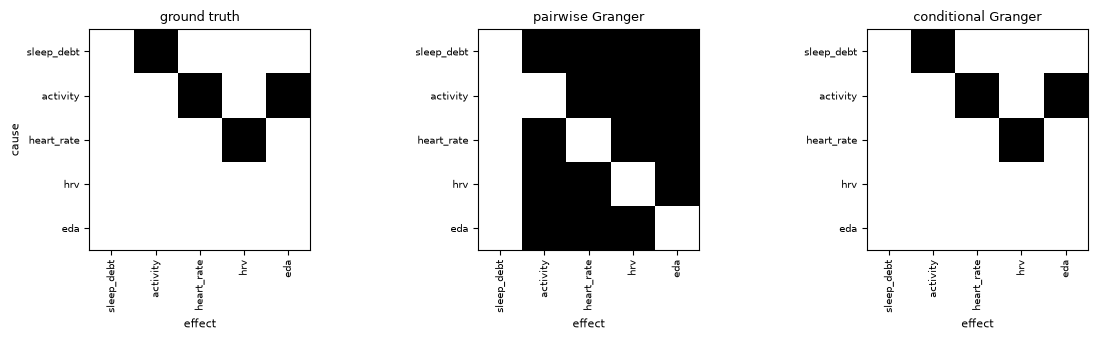

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
truth = np.zeros((5, 5), dtype=bool)
for a, b, _ in cds.true_edges:
    truth[cds.var_names.index(a), cds.var_names.index(b)] = True

panels = [
    ("ground truth", truth),
    ("pairwise Granger", causal.discover_graph(cds, alpha=0.01, conditional=False)),
    ("conditional Granger", causal.discover_graph(cds, alpha=0.01, conditional=True)),
]
for ax, (title, m) in zip(axes, panels):
    ax.imshow(m, cmap="Greys", vmin=0, vmax=1)
    ax.set_xticks(range(5)); ax.set_xticklabels(cds.var_names, rotation=90, fontsize=7)
    ax.set_yticks(range(5)); ax.set_yticklabels(cds.var_names, fontsize=7)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel("effect", fontsize=8)
axes[0].set_ylabel("cause", fontsize=8)
plt.tight_layout(); plt.show()

## Takeaways

- **Pairwise Granger is close to useless on this system.** It fires on nearly
  every ordered pair, because in a system where one driver (`activity`) feeds
  everything, all downstream variables predict each other. High recall, terrible
  precision — a confidently wrong causal story.

- **Conditioning fixes it.** Conditional Granger recovers the true graph
  exactly. The spurious `heart_rate -> eda` edge vanishes once `activity`'s
  history is in the model. This is the single most important practical idea in
  causal discovery for wearables, where nearly every signal is downstream of
  movement and of circadian state.

- **Counterfactuals are the bridge from attribution to causation.** They still
  explain the model rather than the world, but "the smallest edit that changes
  the decision" is a manipulable, checkable claim, and an on-manifold
  counterfactual is something a domain expert can actually critique.

### Honest limitations of what is implemented here

- Both causal tests are **linear VAR** based: they detect linear lagged
  dependence only. A nonlinear driver would be missed.
- Both assume **causal sufficiency** — no unobserved confounders. That assumption
  is routinely false in wearable data (sleep, stress, medication, ambient
  temperature are rarely all measured), and no amount of conditioning on the
  variables you *do* have will fix a confounder you never recorded.
- There is **no multiple-testing correction** across the 20 ordered pairs x 5
  lags. Real PCMCI handles this.
- `discover_graph` treats each ordered pair independently rather than running
  PCMCI's iterative condition-selection, which is what makes real PCMCI scale to
  many variables without the conditioning set exploding.

For real work use [`tigramite`](https://github.com/jakobrunge/tigramite) (the
authors' PCMCI implementation) — nonlinear independence tests, proper
false-discovery control, and the full PCMCI+ algorithm.